In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('02_model_evaluation.ipynb')))
import pandas as pd
results = pd.read_csv('../saved_models/model_results.csv')
print(results)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.805536   0.668919  0.529412  0.591045  0.845914
1        Random Forest  0.790632   0.635739  0.494652  0.556391  0.823036
2              XGBoost  0.779276   0.595166  0.526738  0.558865  0.818841


Training size: (5634, 33)
Test size: (1409, 33)
Churn rate in training: 26.54%


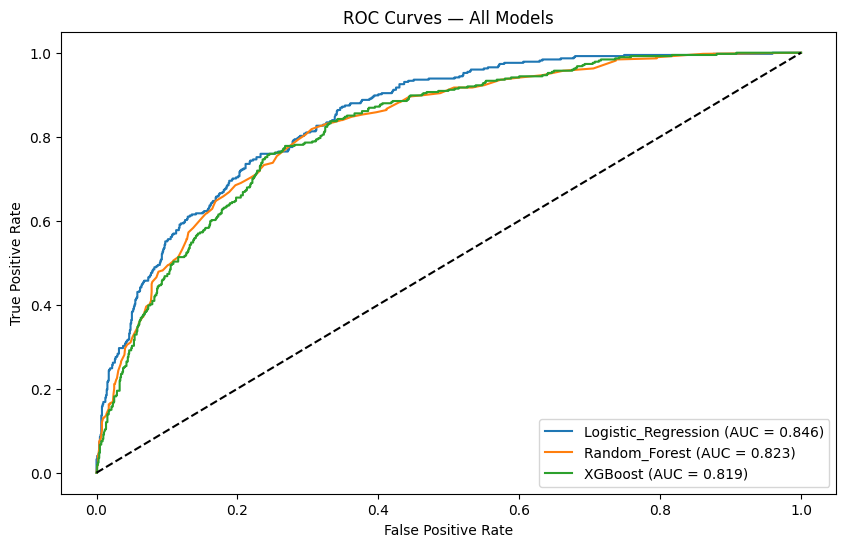

In [2]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import sys
sys.path.append('../preprocessing')
from preprocess import load_and_clean_data, encode_features, feature_engineering, split_and_scale

df = load_and_clean_data('../../data/telco_churn.csv')
df = encode_features(df)
df = feature_engineering(df)
X_train, X_test, y_train, y_test, features = split_and_scale(df)

model_names = ['Logistic_Regression', 'Random_Forest', 'XGBoost']

plt.figure(figsize=(10, 6))
for name in model_names:
    model = joblib.load(f'../saved_models/{name}.pkl')
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.show()